# Filter low quality paraphrases
Find out how many paraphrases are of low quality and filter them out.

Load paraphrases.

In [26]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from pathlib import Path

# sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization.datasets import *
from genai_detection.config import CONFIG
from functools import partial
import gc
import datetime
import json
import textwrap
import pyreadstat
import collections
from datasets import load_from_disk

In [27]:
# student essays test
path2json1 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/impostor_generator_comparison/complete_student_essays_test_dataset_1.json"
)

# student essays test for sim syn
path2json2 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/impostor_generator_comparison/student_essays_naive_llm_test_impostor_scores_syn_sim.json"
)

# detection scenarios Student essays
path2json3 = (
    Path(os.getcwd()).resolve().parent
    / CONFIG.SAVE_PATH
    / "impostor_scores/experiments/detection_scenarios/student_essays_naive_llm_test_impostor_scores_detection_scenarios.json"
)

store_length = pd.DataFrame(
    columns=[
        "reference_text_length",
        "paraphrase_length",
        "smaller700",
        "paraphraser",
        "reference_pair_id",
        "pair_id",
        "realtive_len_perc",
        "prompt",
    ]
)
reference_pair_ids = pd.DataFrame(
    columns=["reference_pair_id", "pair_id", "reference_text"]
)
store_garbage_texts = pd.DataFrame(
    columns=["reference_pair_id", "pair_id", "paraphraser", "garbage"]
)
garbage_texts = ["I sorry, but I can't help with that."]


# read json file
for path2json in [path2json1, path2json2, path2json3]:
    print("Reading json file:", path2json)
    with open(path2json, "r", encoding="utf-8") as f:
        df = json.load(f)

    for i in range(len(df)):  # uppermost list level: dictionary
        item = df[i]
        if "artificial_generation" in item and item["artificial_generation"]:
            # print("Skipping item", i, "because 'artificial_generation' is True, i.e. pair was generated.")
            continue
        if (
            "impostor_dict_naive_llm" not in item
            or item["impostor_dict_naive_llm"] is None
        ):
            # print("Skipping item", i, "because no 'impostor_dict_naive_llm' key found.")
            continue
        pair_dict = item["impostor_dict_naive_llm"]["text_pair_0"]  # dict with two keys

        for (
            no_in_pair,
            imp_dict,
        ) in pair_dict.items():  # dict containing reference text and paraphrases
            reference_text = imp_dict["reference_text"]
            paraphrases_dict = imp_dict["paraphrases"]
            # calculate word counts (split on whitespace)
            ref_len = len(reference_text.split())

            # add reference text info (ensuring no duplicates)
            reference_pair_ids = pd.concat(
                [
                    reference_pair_ids,
                    pd.DataFrame(
                        [
                            {
                                "reference_pair_id": i,  # position in the outermost list
                                "pair_id": no_in_pair,  # "0" or "1"
                                "reference_text": reference_text,
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

            for impostor_name, para in paraphrases_dict.items():  # impostors
                split_name = impostor_name.split("_")
                paraphraser = split_name[-1]
                prompt = split_name[2]

                para_len = len(para.split())
                # check for garbage
                garbage = any(g in para for g in garbage_texts)

                # add length info
                store_length = pd.concat(
                    [
                        store_length,
                        pd.DataFrame(
                            [
                                {
                                    "reference_text_length": ref_len,
                                    "paraphrase_length": para_len,
                                    "smaller700": para_len < 700,
                                    "paraphraser": paraphraser,
                                    "prompt": prompt,
                                    "reference_pair_id": i,  # position in the outermost list
                                    "pair_id": no_in_pair,  # "0" or "1"
                                    "realtive_len_perc": np.round(
                                        (100 / ref_len) * para_len, 2
                                    ),
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )

                # add garbage info
                store_garbage_texts = pd.concat(
                    [
                        store_garbage_texts,
                        pd.DataFrame(
                            [
                                {
                                    "paraphraser": paraphraser,
                                    "garbage": garbage,
                                    "reference_pair_id": i,  # position in the outermost list
                                    "pair_id": no_in_pair,  # "0" or "1"
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )


display(store_length)
# display(store_garbage_texts)
# display(reference_pair_ids)
print("Number of garbage texts:", store_garbage_texts["garbage"].sum())

Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/impostor_generator_comparison/complete_student_essays_test_dataset_1.json
Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/impostor_generator_comparison/student_essays_naive_llm_test_impostor_scores_syn_sim.json


/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_43286/1152156786.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  store_length = pd.concat([


Reading json file: /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/impostor_scores/experiments/detection_scenarios/student_essays_naive_llm_test_impostor_scores_detection_scenarios.json


,reference_text_length,paraphrase_length,smaller700,paraphraser,reference_pair_id,pair_id,realtive_len_perc,prompt
0,794,22,True,mistral-large-instruct,0,0,2.77,prompt0
1,794,242,True,mistral-large-instruct,0,0,30.48,prompt1
2,794,127,True,meta-llama-3.1-8b-instruct,0,0,15.99,prompt0
3,794,175,True,meta-llama-3.1-8b-instruct,0,0,22.04,prompt1
4,794,8,True,openai-gpt-oss-120b,0,0,1.01,prompt0
...,...,...,...,...,...,...,...,...
1046,935,548,True,meta-llama-3.1-8b-instruct,72,1,58.61,prompt1
1047,707,519,True,qwen3-32b,79,0,73.41,prompt0
1048,707,952,False,qwen3-32b,79,0,134.65,prompt1
1049,927,765,False,qwen3-32b,79,1,82.52,prompt0


Number of garbage texts: 0


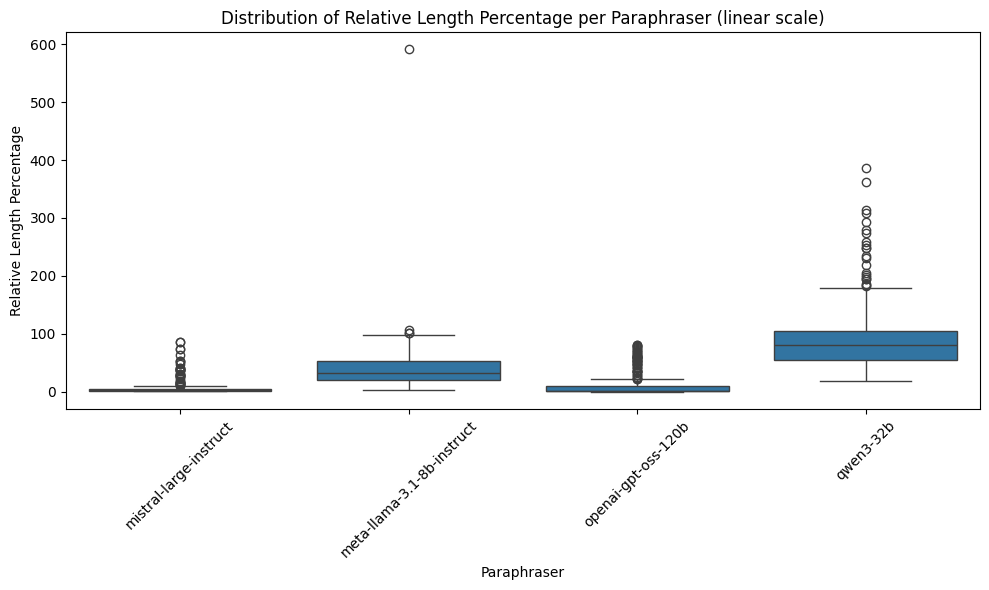

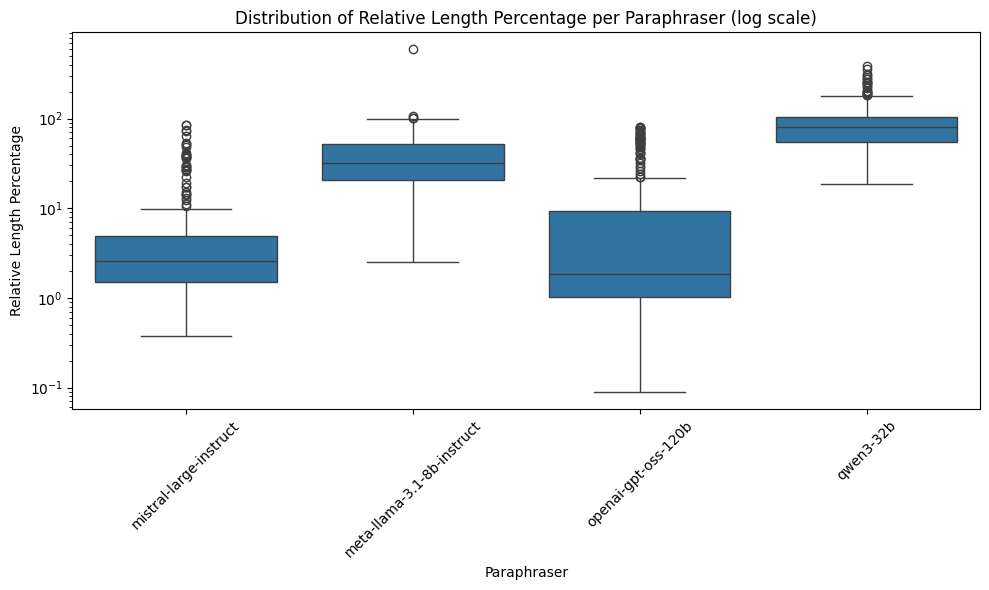

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

for scale in ["linear", "log"]:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="paraphraser", y="realtive_len_perc", data=store_length)

    if scale == "log":
        plt.yscale("log")  # log scale to expand lower region
    plt.title(
        f"Distribution of Relative Length Percentage per Paraphraser ({scale} scale)"
    )
    plt.xlabel("Paraphraser")
    plt.ylabel("Relative Length Percentage")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.close()

In [29]:
import numpy as np

gt_store_length = (
    store_length[["paraphraser", "prompt", "realtive_len_perc"]]
    .groupby(["paraphraser", "prompt"])
    .agg(
        mean_relative_len_perc=("realtive_len_perc", "mean"),
        std_relative_len_perc=("realtive_len_perc", "std"),
        count=("realtive_len_perc", "size"),
    )
    .reset_index()
)

# round floats for readability
gt_store_length = gt_store_length.applymap(
    lambda x: np.round(x, 2) if isinstance(x, float) else x
)
gt_store_length

/var/folders/hk/dwphr0p14vn00wrnlw8bxjpw0000gn/T/ipykernel_43286/782346077.py:15: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  gt_store_length = gt_store_length.applymap(


,paraphraser,prompt,mean_relative_len_perc,std_relative_len_perc,count
0,meta-llama-3.1-8b-instruct,prompt0,39.93,52.64,135
1,meta-llama-3.1-8b-instruct,prompt1,40.27,24.21,124
2,mistral-large-instruct,prompt0,1.89,1.00,138
3,mistral-large-instruct,prompt1,13.09,17.96,129
4,openai-gpt-oss-120b,prompt0,5.53,13.47,139
5,openai-gpt-oss-120b,prompt1,19.21,25.00,129
6,qwen3-32b,prompt0,88.36,70.02,134
7,qwen3-32b,prompt1,95.73,47.72,123
